In [28]:
from astropy.table import Table
from dendrocat import RadioSource
from astropy.io import fits
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import sys
import importlib
from astropy.wcs import WCS
from scipy import interpolate
from astropy import units as u
import radio_beam
from radio_beam import Beam
from astropy import coordinates
from astropy import wcs
from astropy.nddata.utils import Cutout2D
from dendrocat.aperture import Ellipse
from astropy.io import ascii
import astropy.constants as c

from functools import reduce
from itertools import chain
import Paths.Paths as paths

from astropy.modeling import models
Path = paths.filepaths()


class core_catdata():
    def __init__(self,catfile, almaimf_beam,  start_coreno, hrfits=None,band='B3', recommend_criteria = 'b6', include_ff='no' ):
        catdata_w51e = ascii.read(catfile,data_start=0,format='commented_header', header_start=120,  comment="!")
        geo_avg_beam = np.sqrt(almaimf_beam.major.to(u.arcsec).value*almaimf_beam.minor.to(u.arcsec).value)
        corr_factor = catdata_w51e['AFWHM02'] * catdata_w51e['BFWHM02'] / catdata_w51e['AFWHM03'] / catdata_w51e['BFWHM03']
        numcore_tot = len(catdata_w51e['AFWHM02'])
        if include_ff=='all':
            coreno_merged = start_coreno[0] + start_coreno[1]
            print('coreno_merged',coreno_merged)
            coreno_merged.sort()
            coreno_start = coreno_merged
            print('coreno_start',coreno_start)
        elif include_ff=='ffonly':
            coreno_start = start_coreno[1]
        elif include_ff=='no':
            coreno_start = start_coreno[0]
        coreidx_start = [i for i in range(numcore_tot) if catdata_w51e['NO'][i] in coreno_start]
        if recommend_criteria == 'b6b3':
            coreidx = [idx for idx in coreidx_start if all([np.abs(catdata_w51e['GOODM02'][idx])>1,  
                       np.abs(catdata_w51e['SIGNM02'][idx])>1,  
                       catdata_w51e['FXP_BST02'][idx]/catdata_w51e['FXP_ERR02'][idx]>2, 
                       catdata_w51e['FXT_BST02'][idx]/catdata_w51e['FXT_ERR02'][idx]>2, 
                       catdata_w51e['AFWHM02'][idx]/catdata_w51e['BFWHM02'][idx]<2 ,
                        catdata_w51e['FOOA02'][idx]/catdata_w51e['AFWHM02'][idx]>1.15 ,
                        np.sqrt(catdata_w51e['AFWHM03'][idx]*catdata_w51e['BFWHM03'][idx]) <4 * geo_avg_beam  ,
                        catdata_w51e['AFWHM03'][idx]/catdata_w51e['BFWHM03'][idx]<=2 ,
                        np.abs(catdata_w51e['SIGNM03'][idx])>1 ,
                        catdata_w51e['FXP_BST03'][idx]/catdata_w51e['FXP_ERR03'][idx]>1,  
                        catdata_w51e['FXT_BST03'][idx]/catdata_w51e['FXT_ERR03'][idx]>1])]
        elif recommend_criteria == 'b6':
            coreidx = coreidx_start                  
       
        
        if hrfits is not None:
            yso_image = fits.open(hrfits)[0].data[0][0]
            hrhdr = fits.open(hrfits)[0].header
            inside_idx = exist_inside_FOV(catdata_w51e['WCS_ACOOR'], catdata_w51e['WCS_DCOOR'], yso_image, hrhdr)
    
            rec_ind = np.intersect1d(coreidx, inside_idx)
        else:
            rec_ind = coreidx
        print('total core number = ', len(catdata_w51e['WCS_ACOOR']))
        print(hrfits)
        print('robust %s measurement before applying FoV criteria = '%band, len(coreidx))
        print('robust %s measurement after applying FoV criteria = '%band, len(rec_ind))
       
        self.sky_ra = catdata_w51e['WCS_ACOOR'][rec_ind]
        self.sky_dec = catdata_w51e['WCS_DCOOR'][rec_ind]
        self.pix_x = catdata_w51e['XCO_P'][rec_ind]
        self.pix_y = catdata_w51e['YCO_P'][rec_ind]
        
        if band=='B3':
            bandind = 3
        else:
            bandind = 2

        self.afwhm = catdata_w51e['AFWHM0%d'%bandind][rec_ind] #arcsec
        self.bfwhm = catdata_w51e['BFWHM0%d'%bandind][rec_ind]

        self.asize = catdata_w51e['ASIZE0%d'%bandind][rec_ind]
        self.bsize = catdata_w51e['BSIZE0%d'%bandind][rec_ind]

        self.theta = catdata_w51e['THETA0%d'%bandind][rec_ind]
        
        self.flux = catdata_w51e['FXT_BST0%d'%bandind][rec_ind]
        self.fluxerr = catdata_w51e['FXT_ERR0%d'%bandind][rec_ind]
        self.flux_g = catdata_w51e['FXT_ALT0%d'%bandind][rec_ind]

        self.fooa = catdata_w51e['FOOA0%d'%bandind][rec_ind]
        self.foob = catdata_w51e['FOOB0%d'%bandind][rec_ind]
        
        self.int_peak = catdata_w51e['FXP_BST0%d'%bandind][rec_ind]
        self.interr_peak = catdata_w51e['FXP_ERR0%d'%bandind][rec_ind]
        
        self.size = (catdata_w51e['AFWHM0%d'%bandind][rec_ind]*catdata_w51e['BFWHM0%d'%bandind][rec_ind]**2)**(1/3) #arcsec


        self.no = catdata_w51e['NO'][rec_ind]

        
        
        rescaled_3mmflux = catdata_w51e['FXT_BST03'][rec_ind] * catdata_w51e['AFWHM02'][rec_ind] * catdata_w51e['BFWHM02'][rec_ind] / catdata_w51e['AFWHM03'][rec_ind]/catdata_w51e['BFWHM03'][rec_ind]
        gamma = np.log10(catdata_w51e['FXT_BST02'][rec_ind] / rescaled_3mmflux)/np.log10(228.918/101.426)
        self.woffind = np.where(gamma>2)[0]
        self.wffind = np.where(gamma<2)[0]
        self.rec_ind = rec_ind

        
    def get_temperature(self,tempfile,temp100ind = [], temp300ind =[]):
        #temp100ind = hot cores with 100K
        #temp300ind = hot cores with 300K

        tab = ascii.read(tempfile, data_start=4)
        id = tab['col1']
        ra = tab['col2']
        dec = tab['col3']
        temp = tab['col4']

        """
        for i in range(len(self.sky_ra)):
            dist = np.sqrt((self.sky_ra[i]-ra)**2+(self.sky_dec[i]-dec)**2) #deg
            mindist = np.min(dist)
            if mindist<threshold:
                index = np.argmin(dist)
                temparr.append(temp[index])
            else:
                temparr.append(np.nan)
        """
        temparr = np.array([temp[np.where(id==no)[0]][0] for no in self.no])
        for i in range(len(temp100ind)):
            if temp100ind[i] in self.no:
                idx100 = np.where(self.no==temp100ind[i])[0]
                print(idx100)
                temparr[idx100] = 100
                print('#%d core temp -->100K'%temp100ind[i])
        for i in range(len(temp300ind)):
            if temp300ind[i] in self.no:
                idx300 = np.where(self.no==temp300ind[i])[0]
                temparr[idx300] = 300
                print('#%d core temp -->300K'%temp300ind[i])
        self.temp = np.array(temparr)*u.K
        
        return self.temp
    
    def get_tau(self, freq, omega):
        bb = models.BlackBody(temperature=self.temp)
    
        peak_int = (self.int_peak * u.Jy/u.beam).to(u.Jy/u.sr, equivalencies=u.beam_angular_area(omega))

        return -np.log(1 - (peak_int/ bb(freq).to(u.Jy/u.sr)).to(u.cm/u.cm).value)
    
    def get_coremass(self, freq, kappa, dist,omega):
            
        print('self.temp',self.temp)
        bb = models.BlackBody(temperature=self.temp)
        peak_int = (self.int_peak * u.Jy/u.beam).to(u.Jy/ u.sr, equivalencies=u.beam_angular_area(omega))
        print('peak_int',peak_int)
        print('self.flux',self.flux)
        print('kappa',kappa)
        print(bb(freq).to(u.Jy/u.sr))
        mass = - 1 / kappa * dist**2 * self.flux * u.Jy/ u.sr / peak_int * np.log(1 - (peak_int/ bb(freq).to(u.Jy/u.sr)).to(u.cm/u.cm).value)
        print((peak_int/ bb(freq).to(u.Jy/u.sr)).to(u.cm/u.cm).value)
        print(mass)
        print('mass',mass.to(u.Msun))
        self.mass = mass.to(u.Msun)
        return mass.to(u.Msun)
    
    def get_coremasserr(self):
        
        masserr = np.abs(self.mass * np.sqrt((self.fluxerr/self.flux)**2+(self.interr_peak/self.int_peak)**2))
        self.masserr = masserr
        return masserr.to(u.Msun)
                       
    def get_Jeansmass(self, dist=5400):
        rad = (self.afwhm.value*dist * self.bfwhm.value**2*dist**2)**(1/3) #arcsec -> au
        rho = self.mass / (4/3*np.pi * (rad*u.au)**3)
        c_s = np.sqrt(c.k_B*self.temp/2.8/c.m_p)
        jeans_mass = np.pi**(5/2)/6/c.G**(3/2) * c_s.to(u.cm/u.s)**3 * rho.to(u.g/u.cm**3)**(-1/2)
        
        return jeans_mass.to(u.Msun)

    def get_Jeansmasserr(self,dist=5400):
        rad = (self.afwhm.value*dist * self.bfwhm.value**2*dist**2)**(1/3) #arcsec -> au
        rho = self.mass / (4/3*np.pi * (rad*u.au)**3)
        c_s = np.sqrt(c.k_B*self.temp/2.8/c.m_p)
        jeans_mass = np.pi**(5/2)/6/c.G**(3/2) * c_s.to(u.cm/u.s)**3 * rho.to(u.g/u.cm**3)**(-1/2)
        rho_err = self.masserr / (4/3*np.pi * (rad*u.au)**3)

        jeans_mass_err = 0.5*jeans_mass * (rho_err/rho)

        return jeans_mass_err.to(u.Msun)
    def get_BE_mass(self, dist=5400):
        rad = (self.afwhm.value*dist * self.bfwhm.value**2*dist**2)**(1/3)
        rho = self.mass / (4/3*np.pi * (rad*u.au)**3)

        BE_mass = 1.18 * np.sqrt((c.k_B*self.temp/2.33/c.m_p/c.G)**3/rho).to(u.Msun)
        return BE_mass.to(u.Msun)
    
    def get_BE_masserr(self, dist=5400):
        rad = (self.afwhm.value*dist * self.bfwhm.value**2*dist**2)**(1/3)
        rho = self.mass / (4/3*np.pi * (rad*u.au)**3)

        BE_mass = 1.18 * np.sqrt((c.k_B*self.temp/2.33/c.m_p/c.G)**3/rho).to(u.Msun)
        rho_err = self.masserr / (4/3*np.pi * (rad*u.au)**3)

        BE_mass_err = 0.5*BE_mass * (rho_err/rho)
        return BE_mass_err.to(u.Msun)
    
    
    def multiplicity(self, hdrhr, xysource, almaimf_beam=None,issky=True, label=None, aperture='fwhm+beam',limitarea=None,  maxrad=1e3, verbose=False):
        ncat = len(self.no)
        if limitarea is not None:
            posind = np.where((sky_ra>limitarea[0])&(sky_ra<limitarea[1])&
                              (sky_dec>limitarea[2])&(sky_dec<limitarea[3]))[0]
        else:
            posind = np.arange(ncat)
        if label is None:
            label=np.arange(ncat)
        coreidx = np.arange(ncat)

        totalind = np.intersect1d(posind, label)
        print('totalind',totalind)
        sky_ra = self.sky_ra[totalind]
        sky_dec = self.sky_dec[totalind]
        fooa = self.fooa[totalind]
        foob = self.foob[totalind]
        theta = self.theta[totalind]
        no = self.no[totalind]
        afwhm =self.afwhm[totalind]
        bfwhm = self.bfwhm[totalind]

        skypos = np.vstack((sky_ra,sky_dec)).T


        wcshr = WCS(hdrhr,naxis=2)
        scalehr = wcshr.proj_plane_pixel_scales()[0]

        xypos_core = wcshr.wcs_world2pix(skypos,0)
        xpos_core = xypos_core[:,0]
        ypos_core = xypos_core[:,1]

        if issky:
            xysource_pix = wcshr.wcs_world2pix(xysource,0)
        else:
            xysource_pix = xysource
        ysonumarr=[] ; coreindarr=[]; ysoindarr=[]
        prestellar_ind = []
        protostellar_ind = []
        #print(xysource)
        for i in range(len(xypos_core)):
            if aperture is 'footprint':
                major = fooa[i]/3600/scalehr.value
                minor = foob[i]/3600/scalehr.value
                pa = theta[i]+90
            elif aperture is 'fwhm+beam':
                meanbeamsize = (almaimf_beam.major.value+almaimf_beam.minor.value)/4
                major = (afwhm[i]/3600+meanbeamsize)/scalehr.value
                minor = (bfwhm[i]/3600+meanbeamsize)/scalehr.value
                pa = theta[i]+90
            elif aperture is 'beam':
                major = almaimf_beam.major.value/scalehr.value
                minor = almaimf_beam.minor.value/scalehr.value
                pa = almaimf_beam.pa.value+90
            #if major > maxrad:
            #    continue

            numsource, indsource = count_points_in_ellipse(xpos_core[i],ypos_core[i],major,minor,pa,xysource_pix[:,0],xysource_pix[:,1])
            print(totalind[i], indsource, numsource)
            ysonumarr.append(numsource)
            coreindarr.append(totalind[i])
            ysoindarr.append(indsource)
            if numsource==0:
                prestellar_ind.append(totalind[i])
            elif numsource>0:
                protostellar_ind.append(totalind[i])
            
            
      
        ysoindarr_flat = []
        for arr in ysoindarr:
            ysoindarr_flat.extend(arr)
       
        print('cores with/without YSOs ', len(np.where(np.array(ysonumarr)!=0)[0]), len(xpos_core)-len(np.where(np.array(ysonumarr)!=0)[0]))
        print('YSOs associated with cores',len(np.unique(ysoindarr_flat)),' out of ',len(xysource_pix[:,0]))
              
        self.ysonumarr = ysonumarr
        self.coreindarr = coreindarr
        self.ysoindarr = ysoindarr
        self.prestellar_ind = prestellar_ind
        self.protostellar_ind = protostellar_ind
        print('pre,pro',self.prestellar_ind, self.protostellar_ind)
        return ysonumarr, coreindarr, ysoindarr, prestellar_ind, protostellar_ind
        
        
    
        
        
    

                
            
#def BB(freq, temp):
#    B_nu = (2 * freq**3 *c.h / (c.c**2) * 1 / (np.e**(c.h*freq/(c.k_B*temp))-1))
#    return B_nu        

def kappa(nu, nu0=271.1*u.GHz, kappa0=0.0114*u.cm**2*u.g**-1, beta=1.75):
    """
    Compute the opacity $\kappa$ given a reference frequency (or wavelength)
    and a power law governing the opacity as a fuction of frequency:
    $$ \kappa = \kappa_0 \left(\\frac{\\nu}{\\nu_0}\\right)^{\\beta} $$
    The default kappa=0.0114 at 271.1 GHz comes from extrapolating the
    Ossenkopf & Henning 1994 opacities for the thin-ice-mantle, 10^6 year model
    anchored at 1.0 mm with an assumed beta of 1.75.
    Parameters
    ----------
    nu: astropy.Quantity [u.spectral() equivalent]
        The frequency at which to evaluate kappa
    nu0: astropy.Quantity [u.spectral() equivalent]
        The reference frequency at which $\kappa$ is defined
    kappa0: astropy.Quantity [cm^2/g]
        The dust opacity per gram of H2 along the line of sight.  Because of
        the H2 conversion, this factor implicitly includes a dust to gas ratio
        (usually assumed 100)
    beta: float
        The power-law index governing kappa as a function of nu
    """
    return (kappa0*(nu.to(u.GHz,u.spectral())/nu0.to(u.GHz,u.spectral()))**(beta)).to(u.cm**2/u.g)        

     
"""
def get_BEmass(major, minor, temp ):
    rad = (major * minor**2)**(1/3)
    sigma_th = np.sqrt(c.k_B*temp*u.K/(2.4*c.m_p))
    return (2.4*rad*u.au*sigma_th**2/c.G).to(u.Msun)


"""
def count_points_in_ellipse(xcen,ycen,major,minor,pa,xpos,ypos):
    # caclulate foci positions 
    # must be full major, minor not semi major, minor
    fodx = np.cos(pa)*np.sqrt((major/2)**2-(minor/2)**2)
    fody = np.sin(pa)*np.sqrt((major/2)**2-(minor/2)**2)
    
    fox1 = xcen + fodx
    foy1 = ycen + fody
    
    fox2 = xcen - fodx
    foy2 = ycen - fody
    
    dist1 = np.sqrt((xpos-fox1)**2+(ypos-foy1)**2)
    dist2 = np.sqrt((xpos-fox2)**2+(ypos-foy2)**2)
    
    isinside = np.where(dist1+dist2<major)[0]
    
    return len(isinside), list(isinside)



def exist_inside_FOV(xcore_sky, ycore_sky, yso_image, hrhdr):
    isfinite = np.where(np.isfinite(yso_image))
    xfinite1 = np.min(isfinite[0])
    xfinite2 = np.max(isfinite[0])
    yfinite1 = np.min(isfinite[1])
    yfinite2 = np.max(isfinite[1])
     
    xcen = (xfinite1 + xfinite2)/2
    ycen = (yfinite1 + yfinite2)/2

    wcs_hr = WCS(hrhdr,naxis=2)
    xypos = wcs_hr.wcs_world2pix(np.vstack((xcore_sky,ycore_sky)).T,0)
    
    rad = np.abs(xfinite2 - xcen)
    
    
    dist = np.sqrt((xypos[:,0]- xcen)**2+(xypos[:,1]-ycen)**2)
    isinside = np.where(dist<rad)[0]
    
    return isinside


     

### load core data

In [29]:
fitsdata_b3 = fits.open(Path.w51e_b3_tt0)
image_b3_w51e = fitsdata_b3[0].data
if len(image_b3_w51e.shape)>2:
    image_b3_w51e = fitsdata_b3[0].data[0][0]
hdrB3_w51e_hr = fits.getheader(Path.w51e_b3_tt0)  
wcsB3_w51e_hr = WCS(hdrB3_w51e_hr,naxis=2)

fitsdata_b3 = fits.open(Path.w51n_b3_tt0)
image_b3_w51n = fitsdata_b3[0].data
if len(image_b3_w51n.shape)>2:
    image_b3_w51n = fitsdata_b3[0].data[0][0]
hdrB3_w51n_hr = fits.getheader(Path.w51n_b3_tt0)  
wcsB3_w51n_hr = WCS(hdrB3_w51n_hr,naxis=2)

fitsdata_b6 = fits.open(Path.w51e_b6_tt0)
image_b6_w51e = fitsdata_b6[0].data
if len(image_b6_w51e.shape)>2:
    image_b6_w51e = fitsdata_b6[0].data[0][0]
hdrB6_w51e_hr = fits.getheader(Path.w51e_b6_tt0) 
wcsB6_w51e_hr = WCS(hdrB6_w51e_hr,naxis=2) 
    
fitsdata_b6 = fits.open(Path.w51n_b6_tt0)
image_b6_w51n = fitsdata_b6[0].data
if len(image_b6_w51n.shape)>2:
    image_b6_w51n = fitsdata_b6[0].data[0][0]
hdrB6_w51n_hr = fits.getheader(Path.w51n_b6_tt0)  
wcsB6_w51n_hr = WCS(hdrB6_w51n_hr,naxis=2)
hdrB6_w51e_almaimf = fits.getheader(Path.w51e_b6_almaimf)  
wcsB6_w51e_almaimf = WCS(hdrB6_w51e_almaimf,naxis=2)
beamb6_w51e_almaimf = Beam.from_fits_header(hdrB6_w51e_almaimf)  

hdrB3_w51e_almaimf = fits.getheader(Path.w51e_b3_almaimf)  
wcsB3_w51e_almaimf = WCS(hdrB3_w51e_almaimf,naxis=2)
beamb3_w51e_almaimf = Beam.from_fits_header(hdrB3_w51e_almaimf) 

hdrB6_w51n_almaimf = fits.getheader(Path.w51n_b6_almaimf)  
wcsB6_w51n_almaimf = WCS(hdrB6_w51n_almaimf,naxis=2)
beamb6_w51n_almaimf = Beam.from_fits_header(hdrB6_w51n_almaimf)  

hdrB3_w51n_almaimf = fits.getheader(Path.w51n_b3_almaimf)  
wcsB3_w51n_almaimf = WCS(hdrB3_w51n_almaimf,naxis=2)
beamb3_w51n_almaimf = Beam.from_fits_header(hdrB3_w51n_almaimf)  

freqb3=92982346121.91989*u.Hz
freqb6=226691598706.70853*u.Hz
kappa_b3 = kappa(freqb3)
kappa_b6 = kappa(freqb6)
# coreidx = [[non-ff idx],[ff idx]] from Louvet+24
coreidx_w51e_fabien = [[2,4,8,11,12,13,14,15,16,17,19,21,22,26,28,29,33,34,38,39],[1,3,5,6,9,10,18,27]] #30, 31, 20 are discarded because they have duplicated pairs in IRS2
coreidx_w51n_fabien = [[1,2,4,6,7,8,9,10,11,12,13,14,15,16,17,19,20,22,23,24,25,26,27,28,29,31,32,33,34,35,37,38,40,41,42,43,44,45,46,47,48,
49,51,52,53,54,55,57,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,84,85,86,87,88,89,90,91,92,94,95,97,99,100,101,102,104,105,106,107,108,109,111,114,117,119,122,123],
[3,5,18,36,56,58,98,113,118,124]]
print('hohoho',len(coreidx_w51n_fabien[0]))
# catfile, almaimf_beam, hrfits, start_coreno, band='B3', include_ff=False
core_catdata_w51e_b3_b6crit_all = core_catdata(Path.w51e_almaimf_catalog, beamb3_w51e_almaimf,coreidx_w51e_fabien)
core_catdata_w51e_b3_b6crit_b3fov = core_catdata(Path.w51e_almaimf_catalog, beamb3_w51e_almaimf,coreidx_w51e_fabien, hrfits=Path.w51e_b3_tt0)
core_catdata_w51e_b3_b6crit_b6fov = core_catdata(Path.w51e_almaimf_catalog, beamb3_w51e_almaimf, coreidx_w51e_fabien, hrfits=Path.w51e_b6_tt0)

core_catdata_w51e_b6_b6crit_b3fov = core_catdata(Path.w51e_almaimf_catalog,beamb3_w51e_almaimf,  coreidx_w51e_fabien, hrfits=Path.w51e_b3_tt0, band='B6',)
core_catdata_w51e_b6_b6crit_b6fov = core_catdata(Path.w51e_almaimf_catalog,beamb3_w51e_almaimf,  coreidx_w51e_fabien, hrfits=Path.w51e_b6_tt0, band='B6')

core_catdata_w51e_b6_b6crit_b3fov_wff = core_catdata(Path.w51e_almaimf_catalog,beamb3_w51e_almaimf,  coreidx_w51e_fabien, hrfits=Path.w51e_b3_tt0,band='B6', include_ff='all')


core_catdata_w51e_b3_b6b3crit_b3fov = core_catdata(Path.w51e_almaimf_catalog, beamb3_w51e_almaimf,coreidx_w51e_fabien,  hrfits=Path.w51e_b3_tt0,  recommend_criteria='b6b3')
core_catdata_w51e_b3_b6b3crit_b6fov = core_catdata(Path.w51e_almaimf_catalog, beamb3_w51e_almaimf,  coreidx_w51e_fabien,hrfits =Path.w51e_b6_tt0,recommend_criteria='b6b3')

core_catdata_w51e_b6_b6b3crit_b3fov = core_catdata(Path.w51e_almaimf_catalog, beamb3_w51e_almaimf, coreidx_w51e_fabien, hrfits = Path.w51e_b3_tt0, band='B6', recommend_criteria='b6b3')
core_catdata_w51e_b6_b6b3crit_b6fov = core_catdata(Path.w51e_almaimf_catalog, beamb3_w51e_almaimf, coreidx_w51e_fabien, hrfits= Path.w51e_b6_tt0, band='B6', recommend_criteria='b6b3')

core_catdata_w51n_b3_b6crit_all = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf,coreidx_w51e_fabien)

core_catdata_w51n_b3_b6crit_b3fov = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf,coreidx_w51n_fabien,hrfits = Path.w51n_b3_tt0)
core_catdata_w51n_b3_b6crit_b6fov = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf,coreidx_w51n_fabien,hrfits =Path.w51n_b6_tt0)

core_catdata_w51n_b6_b6crit_b3fov = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf, coreidx_w51n_fabien,hrfits = Path.w51n_b3_tt0,band='B6')
core_catdata_w51n_b6_b6crit_b6fov = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf, coreidx_w51n_fabien,hrfits = Path.w51n_b6_tt0,band='B6')

core_catdata_w51n_b3_b6b3crit_b3fov = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf,  coreidx_w51n_fabien,hrfits = Path.w51n_b3_tt0,recommend_criteria='b6b3')
core_catdata_w51n_b3_b6b3crit_b6fov = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf,  coreidx_w51n_fabien,hrfits = Path.w51n_b6_tt0,recommend_criteria='b6b3')

core_catdata_w51n_b6_b6b3crit_b3fov = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf, coreidx_w51n_fabien,hrfits = Path.w51n_b3_tt0,band='B6', recommend_criteria='b6b3')
core_catdata_w51n_b6_b6b3crit_b6fov = core_catdata(Path.w51n_almaimf_catalog, beamb3_w51n_almaimf,  coreidx_w51n_fabien,hrfits = Path.w51n_b6_tt0, band='B6', recommend_criteria='b6b3')



hohoho 99
total core number =  41
None
robust B3 measurement before applying FoV criteria =  20
robust B3 measurement after applying FoV criteria =  20
total core number =  41
/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51e2.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits
robust B3 measurement before applying FoV criteria =  20
robust B3 measurement after applying FoV criteria =  20
total core number =  41
/orange/adamginsburg/w51/TaehwaYoo/w51e_b6_imaging_2025/w51e2.spw0thru19.14500.robust0.thr0.1mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits
robust B3 measurement before applying FoV criteria =  20
robust B3 measurement after applying FoV criteria =  13
total core number =  41
/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51e2.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits
robust B6 measurement before applying FoV criteria =  20
r

### load PPO data

In [30]:
catalog_w51e_yso = Table.read(Path.w51e_dendro_matched_catalog_new ,format='fits')
print(catalog_w51e_yso)


yso_w51e_xsky_b6 = catalog_w51e_yso['b6_xsky'] ; yso_w51e_ysky_b6 = catalog_w51e_yso['b6_ysky']
yso_w51e_xsky_b3 = catalog_w51e_yso['b3_xsky'] ; yso_w51e_ysky_b3 = catalog_w51e_yso['b3_ysky']

yso_detect_w51e_b6 = np.where(yso_w51e_xsky_b6>0)[0]
yso_detect_w51e_b3 = np.where(yso_w51e_xsky_b3>0)[0]


catalog_w51n_yso = Table.read(Path.w51n_dendro_matched_catalog_new ,format='fits')
yso_w51n_xsky_b6 = catalog_w51n_yso['b6_xsky'] ; yso_w51n_ysky_b6 = catalog_w51n_yso['b6_ysky']
yso_w51n_xsky_b3 = catalog_w51n_yso['b3_xsky'] ; yso_w51n_ysky_b3 = catalog_w51n_yso['b3_ysky']


yso_xsky_w51e = []
for i,x in enumerate(yso_w51e_xsky_b6):
    if x > 0:
        yso_xsky_w51e.append(x)
    else:
        yso_xsky_w51e.append(yso_w51e_xsky_b3[i])
yso_ysky_w51e = []
for i,x in enumerate(yso_w51e_ysky_b6):
    if x > 0:
        yso_ysky_w51e.append(x)
    else:
        yso_ysky_w51e.append(yso_w51e_ysky_b3[i])

yso_xsky_w51n = []
for i,x in enumerate(yso_w51n_xsky_b6):
    if x > 0:
        yso_xsky_w51n.append(x)
    else:
        yso_xsky_w51n.append(yso_w51n_xsky_b3[i])
yso_ysky_w51n = []
for i,x in enumerate(yso_w51n_ysky_b6):
    if x > 0:
        yso_ysky_w51n.append(x)
    else:
        yso_ysky_w51n.append(yso_w51n_ysky_b3[i])


yso_xsky_w51e = catalog_w51e_yso['ra']
yso_ysky_w51e = catalog_w51e_yso['dec']
yso_xsky_w51n = catalog_w51n_yso['ra']
yso_ysky_w51n = catalog_w51n_yso['dec']
"""
#whether the core is inside the FOV
isinside_w51e_b3fov_b6crit = exist_inside_FOV(core_catdata_w51e_b6_b6crit.sky_ra, core_catdata_w51e_b6_b6crit.sky_dec, image_b3_w51e, hdrB3_w51e_hr) 
isinside_w51e_b6fov_b6crit = exist_inside_FOV(core_catdata_w51e_b6_b6crit.sky_ra, core_catdata_w51e_b6_b6crit.sky_dec, image_b6_w51e, hdrB6_w51e_hr)
isinside_w51n_b3fov_b6crit = exist_inside_FOV(core_sky_ra_w51n_b6, core_sky_dec_w51n_b6, image_b3_w51n, hdrB3_w51n_hr)
isinside_w51n_b6fov_b6crit = exist_inside_FOV(core_sky_ra_w51n_b6, core_sky_dec_w51n_b6, image_b6_w51n, hdrB6_w51n_hr)


#print('ho',isinside_w51e_b3)
isinside_w51e_b3fov_woff = np.intersect1d(isinside_w51e_b3fov,  core_catdata_w51e_b3.woffind)
isinside_w51n_b3fov_woff = np.intersect1d(isinside_w51n_b3fov,  core_catdata_w51n_b3.woffind)
isinside_w51e_b6fov_woff = np.intersect1d(isinside_w51e_b6fov,  core_catdata_w51e_b6.woffind)
isinside_w51n_b6fov_woff = np.intersect1d(isinside_w51n_b6fov,  core_catdata_w51n_b6.woffind)
#print(isinside_w51e_b3_woff)

isinside_w51e_b3fov_wff = np.intersect1d(isinside_w51e_b3fov,  core_catdata_w51e_b3.wffind)
isinside_w51n_b3fov_wff = np.intersect1d(isinside_w51n_b3fov,  core_catdata_w51n_b3.wffind)
isinside_w51e_b6fov_wff = np.intersect1d(isinside_w51e_b6fov,  core_catdata_w51e_b6.wffind)
isinside_w51n_b6fov_wff = np.intersect1d(isinside_w51n_b6fov,  core_catdata_w51n_b6.wffind)
"""

yso_xysource_w51e= np.vstack((yso_xsky_w51e, yso_ysky_w51e)).T
yso_xysource_w51n= np.vstack((yso_xsky_w51n, yso_ysky_w51n)).T

hdrhr_w51n_b3= fits.getheader(Path.w51n_b3_tt0) 
hdrhr_w51e_b3= fits.getheader(Path.w51e_b3_tt0) 
hdrhr_w51n_b6= fits.getheader(Path.w51n_b6_tt0) 
hdrhr_w51e_b6= fits.getheader(Path.w51e_b6_tt0) 

ysogroup_w51e = catalog_w51e_yso['group']
ysogroup_w51n = catalog_w51n_yso['group']


isincore_w51e_b3 = catalog_w51e_yso['inincore_b3fov'] 
isincore_w51n_b3 = catalog_w51n_yso['inincore_b3fov'] 
isoutcore_w51e_b3 = np.where(~catalog_w51e_yso['inincore_b3fov'])[0] 
isoutcore_w51n_b3 = np.where(~catalog_w51n_yso['inincore_b3fov'])[0] 






 b3_id     b6_id   b3_xpix ...    MBBT_mass_err     inincore_b3fov
                           ...       solMass                      
-------- --------- ------- ... -------------------- --------------
93030993 226003756  7566.0 ...  0.15111758460583466          False
93031160 226003903  7543.0 ...                   --           True
93031210 226003934  7501.0 ...                   --           True
93031450 226004041  7496.0 ... 0.018993029973275444           True
93033120 226005282  7603.0 ...  0.05038512154564974          False
93033295 226005298  7436.0 ...  0.26702457537951824          False
93033484 226005328  7423.0 ...                   --          False
93034136 226005550  8088.0 ...                   --          False
93034470 226005765  7548.0 ...  0.08347537357297324          False
93034661 226005801  7488.0 ...                   --          False
     ...       ...     ... ...                  ...            ...
93019416        --  9845.0 ...                   --           

### link PPO and cores

In [31]:
from collections import Iterable
def flatten(lis):
     for item in lis:
         if isinstance(item, Iterable) and not isinstance(item, str):
             for x in flatten(item):
                 yield x
         else:        
             yield item
core_catdata_w51n_b6_b6crit_b3fov_wff = core_catdata(Path.w51n_almaimf_catalog,beamb3_w51n_almaimf,  
                                                     coreidx_w51n_fabien, hrfits=Path.w51n_b3_tt0,band='B6', include_ff='all')

multiplicity_w51e_b6crit_b3fov = core_catdata_w51e_b6_b6crit_b3fov.multiplicity(hdrhr_w51e_b3,yso_xysource_w51e,
                                 almaimf_beam = beamb6_w51e_almaimf)


w51e_cappo_woff = list(flatten(multiplicity_w51e_b6crit_b3fov[2]))

print('ho',multiplicity_w51e_b6crit_b3fov[2])
multiplicity_w51n_b6crit_b3fov = core_catdata_w51n_b6_b6crit_b3fov.multiplicity(hdrhr_w51n_b3,yso_xysource_w51n,
                                 almaimf_beam = beamb6_w51n_almaimf,)

w51n_cappo_woff = list(flatten(multiplicity_w51n_b6crit_b3fov[2]))

multiplicity_w51e_b6crit_b3fov_wff = core_catdata_w51e_b6_b6crit_b3fov_wff.multiplicity(hdrhr_w51e_b3,yso_xysource_w51e,
                                 almaimf_beam = beamb6_w51e_almaimf)

w51e_cappo_wff = list(flatten(multiplicity_w51e_b6crit_b3fov_wff[2]))
multiplicity_w51n_b6crit_b3fov_wff = core_catdata_w51n_b6_b6crit_b3fov_wff.multiplicity(hdrhr_w51n_b3,yso_xysource_w51n,
                                 almaimf_beam = beamb6_w51n_almaimf,)

w51n_cappo_wff = list(flatten(multiplicity_w51n_b6crit_b3fov_wff[2]))
print(w51e_cappo_woff, w51n_cappo_woff)
print(w51e_cappo_wff, w51n_cappo_wff)



w51e_onlyff = [i for i in w51e_cappo_wff if i not in w51e_cappo_woff]
w51n_onlyff = [i for i in w51n_cappo_wff if i not in w51n_cappo_woff]
print(len(w51e_cappo_wff), len(w51n_onlyff))
print(w51e_onlyff, w51n_onlyff)
print(len(w51e_onlyff), len(w51n_onlyff))
with open('w51e_onlyff.dat', 'w') as f:
    for item in w51e_onlyff:
        f.write("%s\n" % item)
with open('w51n_onlyff.dat', 'w') as f:
    for item in w51n_onlyff:
        f.write("%s\n" % item)





coreno_merged [1, 2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 57, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 84, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 97, 99, 100, 101, 102, 104, 105, 106, 107, 108, 109, 111, 114, 117, 119, 122, 123, 3, 5, 18, 36, 56, 58, 98, 113, 118, 124]
coreno_start [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 84, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 97, 98, 99, 100, 101, 102, 104, 105, 106, 107, 108, 109, 111, 113, 114, 117, 118, 119, 122, 123, 124]


total core number =  127
/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51n.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits
robust B6 measurement before applying FoV criteria =  109
robust B6 measurement after applying FoV criteria =  97
totalind [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
0 [39, 40] 2
1 [29, 30, 31, 32, 33] 5
2 [50, 55, 56, 57, 58, 83] 6
3 [110] 1
4 [36, 96] 2
5 [1, 2, 3] 3
6 [51, 54, 82] 3
7 [44, 45] 2
8 [20, 21, 22, 74, 75] 5
9 [71, 72, 112] 3
10 [63] 1
11 [107] 1
12 [108] 1
13 [] 0
14 [34] 1
15 [] 0
16 [] 0
17 [67] 1
18 [] 0
19 [] 0
cores with/without YSOs  15 5
YSOs associated with cores 37  out of  118
pre,pro [13, 15, 16, 18, 19] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 17]
ho [[39, 40], [29, 30, 31, 32, 33], [50, 55, 56, 57, 58, 83], [110], [36, 96], [1, 2, 3], [51, 54, 82], [44, 45], [20, 21, 22, 74, 75], [71, 72, 112], [63], [107], [108], [], [34], [], [], [67],

### make merged image

In [32]:
from reproject import reproject_interp, reproject_adaptive
from reproject.mosaicking import find_optimal_celestial_wcs
import astropy.units as u
from matplotlib.patches import Rectangle, Ellipse, Circle
from matplotlib import colors
import matplotlib as mpl
from numpy.ma import masked_array
from astropy import stats
from itertools import chain
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams['axes.labelsize']=40
plt.rcParams['xtick.labelsize']=40
plt.rcParams['ytick.labelsize']=40
plt.rcParams['axes.titlesize']=40
mpl.rcParams['axes.linewidth'] = 5

def get_noise_from_background(noiseregionfile, image, wcsNB):
    noiseregion = Regions.read(noiseregionfile,format='ds9')
    container = []
    for reg in noiseregion:
        pix_reg = reg.to_pixel(wcsNB)
        noisemask = pix_reg.to_mask()
        noiseim = noisemask.cutout(image)
        container.append(noiseim.flatten())
    noiseim = list(chain.from_iterable(container))
    std = stats.mad_std(noiseim,ignore_nan=True)
    return std

def cut_image_above_line(image, point1, point2, enditer,alongdir='x', cut_above=True):
    if alongdir=='x':
        iternum = enditer - point1[0]
            
    else:
        iternum = point1[1] - point2[1]
        
    aa = (point2[1] - point2[0]) / (point1[1]-point1[0])
    bb = point2[1] - aa * point2[0]
    if iternum>0:
        step=1
    else:
        step=-1
    iter = np.arange(0, iternum, step)
    for i in iter:
      
        if alongdir=='x':
            start = point1[0]
            yy = int(aa * (start+i) + bb)
            if cut_above:
                image[yy:,start+i] = np.nan
            else:
                image[:yy,start+i] = np.nan
        
        else:
            start = np.min([point1[1], point2[1]])
            yy = aa * (start+i) + bb
            if cut_above:
                image[yy:,start+i] = np.nan
            else:
                image[:yy,start+i] = np.nan
    return image

def add_scale_bar(ax, xpos,ypos,scale, pixel_scale, dist, unit='pc',height=20,color='w',pad=40,size=40,xoffset=0.05):
    phy_pix_scale = (pixel_scale * dist).to(u.kpc*u.rad)/u.rad
    print(phy_pix_scale.to(u.au))
    scaled_scale = (scale/phy_pix_scale).to(u.rad/u.rad)
    print(scaled_scale)
    ax.add_patch(Rectangle((xpos,ypos),scaled_scale.value,height,color=color))
    ax.text(xpos+(0.4+xoffset)*scaled_scale, ypos+pad, '%d %s'%(scale.value, unit), color=color,fontsize=size)
                
def add_beam(ax,xpos,ypos,beam, pixel_scale,color='w',square=False,square_size=800):
    width = beam.major / pixel_scale
    height = beam.minor /pixel_scale
    angle = beam.pa
    ax.add_patch(Ellipse((xpos,ypos),width.value,height.value,180-angle.value,color=color))
    if square:
        ax.scatter(xpos,ypos,facecolor='none', edgecolor=color,s=square_size,marker='s')



def draw_field_of_view(ax, image_highres, wcs_highres, wcs_lowres, color='r', lw=2, ls='dotted'):
    center = int(image_highres.shape[0]/2)
    index = np.where(np.isnan(image_highres[center,:])==False)[0]
    sky0 = wcs_highres.pixel_to_world(center, np.min(index))
    sky1 = wcs_highres.pixel_to_world(center, np.max(index))
    pix0_in_lowres = wcs_lowres.world_to_pixel(sky0)
    pix1_in_lowres = wcs_lowres.world_to_pixel(sky1)

    circle= Circle(( 
    pix0_in_lowres[0], (pix0_in_lowres[1].item()+pix1_in_lowres[1].item())/2),
    radius=(pix1_in_lowres[1].item()-pix0_in_lowres[1].item())/2, color=color,fill=False, lw=lw, ls=ls)
    ax.add_patch(circle)
        

[3976.95723751 4089.38305564 4093.1157463  4084.58210018 4074.98190791
 3987.30130968 3980.58143847 3980.68788026 3973.11451514 3787.32575067
 3930.49498168 3875.73423708 4091.08898337 4132.68860378 4079.67483142
 4034.33235239 3999.87855479 4558.68525167 4451.90881221 3075.61185522
 3672.18969867 3307.43523132 3347.00859273 3307.80810957 3309.30094514
 3300.71342525 3307.24613278 3289.88621824 2811.83282536 3296.22767962
 2903.66422239 4891.45069199 3550.24159213 4161.9191083  4173.8656747
 4158.18517746]
[3331.47912573 3342.68758453 3351.22119861 3355.3805565  3357.93983416
 3365.93323695 3364.22606469 3367.21273933 3367.63883616 3412.98465571
 3466.75555827 3282.83150987 3352.5010461  3357.51750923 3363.38018718
 3484.87010722 3491.05418146 2719.01672817 2759.88859883 2807.94378016
 2923.72255657 3026.17477367 3025.80445479 3032.1481354  3038.68158243
 3049.88092825 3058.09475919 3056.97343681 3057.68368421 3125.2939196
 3170.62401351 3522.2687244  3642.56659461 4024.71983457 4026.0

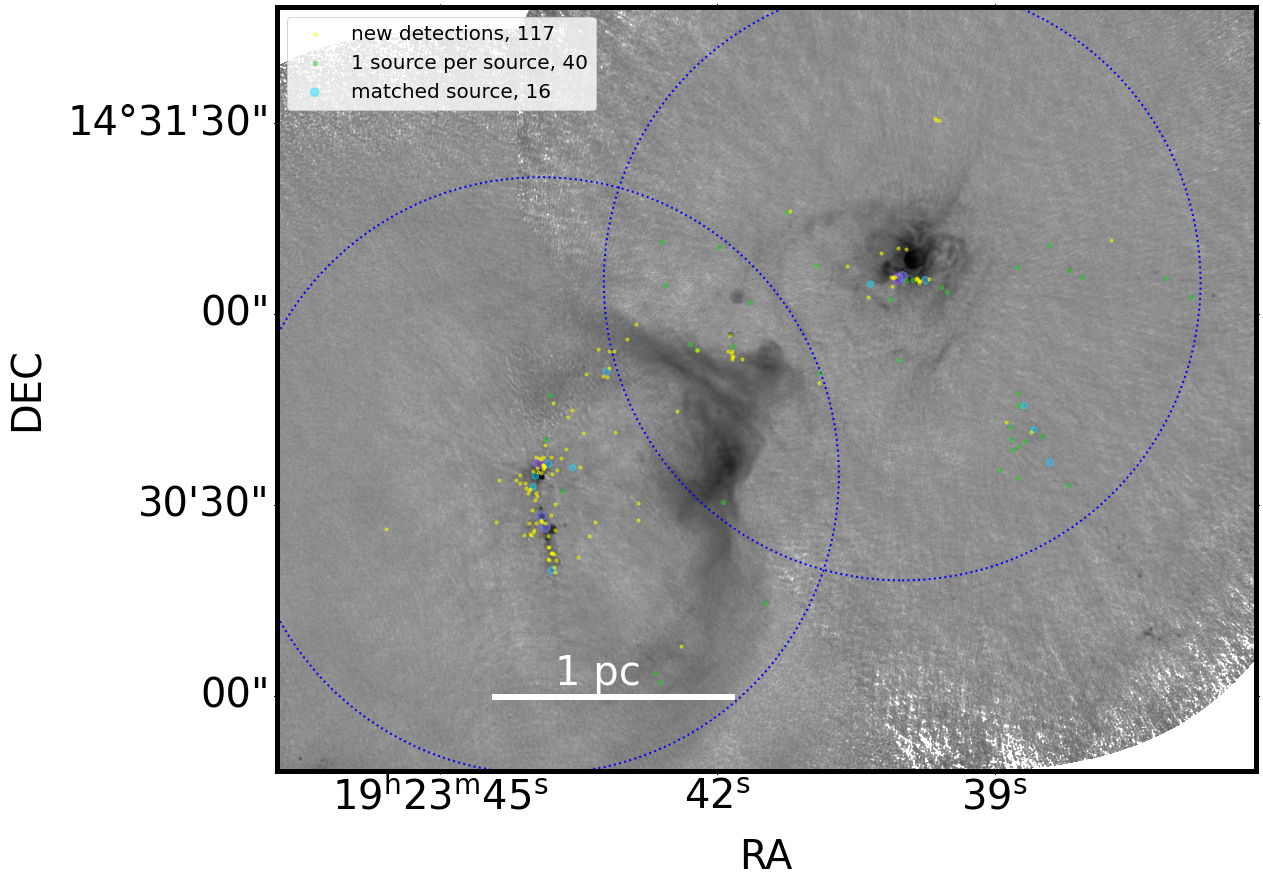

In [33]:
from astropy.visualization import simple_norm
from astropy.stats import mad_std

fitsdata_w51e = fits.open(Path.w51e_b3_almaimf)
image_w51e = fitsdata_w51e[0].data
if len(image_w51e.shape)>2:
    image_w51e = fitsdata_w51e[0].data[0][0]
wcs_w51e = WCS(fitsdata_w51e[0].header,naxis=2)

fitsdata_w51n = fits.open(Path.w51n_b3_almaimf)
image_w51n = fitsdata_w51n[0].data
if len(image_w51n.shape)>2:
    image_w51n = fitsdata_w51n[0].data[0][0]
wcs_w51n = WCS(fitsdata_w51n[0].header,naxis=2)


scale_w51e = wcs_w51e.proj_plane_pixel_scales()[0]

wcs_out, shape_out = find_optimal_celestial_wcs([(image_w51e, wcs_w51e),(image_w51n, wcs_w51n)])

image_w51n_reprojected, footprint = reproject_interp((image_w51n, wcs_w51n), wcs_out, shape_out)

cut_image_above_line(image_w51e, [2410, 4409], [4091, 1290], 4510)
fig = plt.figure(figsize=(20,20))
ax1 = fig.add_axes([0.3,0.3,0.68,0.68], projection=wcs_w51e)

mad1 = mad_std(image_w51n, ignore_nan=True)
norm1 = simple_norm(image_w51n, stretch='log', min_cut=-3*mad1, max_cut=150*mad1)

ax1.imshow(image_w51n_reprojected, origin='lower',cmap=plt.get_cmap('gray_r'),norm=norm1)

ax1.imshow(image_w51e, origin='lower',cmap=plt.get_cmap('gray_r'),norm=norm1)

yso_xysky_w51e =np.vstack((yso_xsky_w51e, yso_ysky_w51e)).T
yso_xysky_w51n = np.vstack((yso_xsky_w51n, yso_ysky_w51n)).T
yso_xpix_w51e = wcs_w51e.wcs_world2pix(yso_xysky_w51e, 0)[:,0]
yso_ypix_w51e = wcs_w51e.wcs_world2pix(yso_xysky_w51e, 0)[:,1]
yso_xpix_w51n = wcs_w51e.wcs_world2pix(yso_xysky_w51n, 0)[:,0]
yso_ypix_w51n = wcs_w51e.wcs_world2pix(yso_xysky_w51n, 0)[:,1]


core_xsky_w51e = core_catdata_w51e_b3_b6crit_b3fov.sky_ra 
core_ysky_w51e = core_catdata_w51e_b3_b6crit_b3fov.sky_dec
core_xysky_w51e = np.vstack((core_xsky_w51e, core_ysky_w51e)).T
core_xpix_w51e = wcs_w51e.wcs_world2pix(core_xysky_w51e, 0)[:,0]
core_ypix_w51e = wcs_w51e.wcs_world2pix(core_xysky_w51e, 0)[:,1]

core_xsky_w51n = core_catdata_w51n_b3_b6crit_b3fov.sky_ra
core_ysky_w51n = core_catdata_w51n_b3_b6crit_b3fov.sky_dec
core_xysky_w51n = np.vstack((core_xsky_w51n, core_ysky_w51n)).T
core_xpix_w51n = wcs_w51e.wcs_world2pix(core_xysky_w51n, 0)[:,0]
core_ypix_w51n = wcs_w51e.wcs_world2pix(core_xysky_w51n, 0)[:,1]

w51e_ppo_num = np.array(multiplicity_w51e_b6crit_b3fov[0])
onesourceind_w51e = np.where(w51e_ppo_num==1)[0]
w51n_ppo_num = np.array(multiplicity_w51n_b6crit_b3fov[0])
onesourceind_w51n = np.where(w51n_ppo_num==1)[0]

moresourceind_w51e = np.where(w51e_ppo_num>1)[0]
moresourceind_w51n = np.where(w51n_ppo_num>1)[0]

w51e_ppo_num_moresources = w51e_ppo_num[moresourceind_w51e]
w51n_ppo_num_moresources = w51n_ppo_num[moresourceind_w51n]


num_new_detections = len(isoutcore_w51e_b3) + len(isoutcore_w51n_b3)
print(yso_xpix_w51n[isoutcore_w51n_b3])
print(yso_ypix_w51n[isoutcore_w51n_b3])
ax1.scatter(yso_xpix_w51e[isoutcore_w51e_b3], yso_ypix_w51e[isoutcore_w51e_b3], s=10, color='yellow', label='new detections, %d'%num_new_detections, zorder=10, alpha=0.5)
ax1.scatter(yso_xpix_w51n[isoutcore_w51n_b3], yso_ypix_w51n[isoutcore_w51n_b3], s=10, color='yellow', zorder=10, alpha=0.5)

num_onesource = len(onesourceind_w51e) + len(onesourceind_w51n)
ax1.scatter(core_xpix_w51e[onesourceind_w51e], core_ypix_w51e[onesourceind_w51e], s=20, color = '#33cc33', label='1 source per source, %d'%num_onesource, zorder=7, alpha=0.5)
ax1.scatter(core_xpix_w51n[onesourceind_w51n], core_ypix_w51n[onesourceind_w51n], s=20, color = '#33cc33', zorder=7, alpha=0.5)

cmap = plt.cm.cool  # define the colormap
# extract all colors from the .jet map
cmaplist = [cmap(i) for i in range(cmap.N)]
# force the first color entry to be grey
cmaplist[0] = (.2, .8, .2, 1.0)
#cmaplist[0] = (0.8039, 0.1961, 0.8039, 1.0)

# create the new map
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)
bounds = np.linspace(1, 10, 10)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

colors_w51e = np.array(np.append(w51e_ppo_num_moresources,1))
colors_w51n = np.array(np.append(w51n_ppo_num_moresources,1))
sizes_w51e = np.array(np.append(w51e_ppo_num_moresources,1))
sizes_w51n = np.array(np.append(w51n_ppo_num_moresources,1))
core_xpix_w51e_moresource = np.append(core_xpix_w51e[moresourceind_w51e], -1)
core_ypix_w51e_moresource = np.append(core_ypix_w51e[moresourceind_w51e], -1)
core_xpix_w51n_moresource = np.append(core_xpix_w51n[moresourceind_w51n], -1)
core_ypix_w51n_moresource = np.append(core_ypix_w51n[moresourceind_w51n], -1)
num_moresources = len(moresourceind_w51e)+len(moresourceind_w51n)
print(colors_w51e, colors_w51n)
print(sizes_w51e, sizes_w51n)
ax1.scatter(core_xpix_w51e_moresource, core_ypix_w51e_moresource ,c = colors_w51e, s = sizes_w51e*20, cmap = cmap, label='matched source, %d'%num_moresources, norm=norm, zorder=5, alpha=0.5)
ax1.scatter(core_xpix_w51n_moresource, core_ypix_w51n_moresource ,c = colors_w51n, s = sizes_w51n*20, cmap = cmap, norm=norm, zorder=4, alpha=0.5)
ax1.legend(fontsize=20)

draw_field_of_view(ax1, image_b3_w51e, wcsB3_w51e_hr, wcs_out, color='b', lw=2, ls='dotted')
draw_field_of_view(ax1, image_b3_w51n, wcsB3_w51n_hr, wcs_out, color='b', lw=2, ls='dotted')
add_scale_bar(ax1,2300,1600, 1*u.pc, scale_w51e, 5.41*u.kpc,xoffset=-0.14, pad=60)
ax1.set_xlim(1400,5500)
ax1.set_ylim(1300,4500)
ax1.set_xlabel('RA' ,fontsize=40)
ax1.set_ylabel('DEC', fontsize=40)